##### EDA For Songs csv

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

In [3]:
df2= pd.read_csv("songs.csv")

In [4]:
df2.head(5)

,song_id,song_length,genre_ids,artist_name,composer,lyricist,language
0,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,247640,465,張信哲 (Jeff Chang),董貞,何啟弘,3.0
1,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=,197328,444,BLACKPINK,TEDDY| FUTURE BOUNCE| Bekuh BOOM,TEDDY,31.0
2,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=,231781,465,SUPER JUNIOR,NaN,NaN,31.0
3,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=,273554,465,S.H.E,湯小康,徐世珍,3.0
4,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=,140329,726,貴族精選,Traditional,Traditional,52.0


In [5]:
df2.shape

(2296320, 7)

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296320 entries, 0 to 2296319
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   song_id      object 
 1   song_length  int64  
 2   genre_ids    object 
 3   artist_name  object 
 4   composer     object 
 5   lyricist     object 
 6   language     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 122.6+ MB


In [7]:
df2.describe(include ='all')

,song_id,song_length,genre_ids,artist_name,composer,lyricist,language
count,2296320,2.296320e+06,2202204,2296320,1224962,351014,2.296319e+06
unique,2296320,NaN,1045,222363,329822,110924,NaN
top,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,NaN,465,Various Artists,Neuromancer,Traditional,NaN
freq,1,NaN,567911,145916,17888,1751,NaN
mean,NaN,2.469935e+05,NaN,NaN,NaN,NaN,3.237800e+01
std,NaN,1.609200e+05,NaN,NaN,NaN,NaN,2.433241e+01
min,NaN,1.850000e+02,NaN,NaN,NaN,NaN,-1.000000e+00
25%,NaN,1.836000e+05,NaN,NaN,NaN,NaN,-1.000000e+00
50%,NaN,2.266270e+05,NaN,NaN,NaN,NaN,5.200000e+01
75%,NaN,2.772690e+05,NaN,NaN,NaN,NaN,5.200000e+01


In [8]:
df2.isnull().sum()

song_id              0
song_length          0
genre_ids        94116
artist_name          0
composer       1071358
lyricist       1945306
language             1
dtype: int64

##### 🛑 Median, Mode, KNN → Not appropriate for free-text, high-cardinality categorical data
##### ✅ Fill with 'unknown' or 'missing' → Keeps data usable and interpretable
##### 🧠 Later, encode "unknown" as a separate class for ML models

In [10]:
# Fill missing values with 'unknown' for text fields
df2['genre_ids'].fillna('unknown_genre', inplace=True)
df2['composer'].fillna('unknown_composer', inplace=True)
df2['lyricist'].fillna('unknown_lyricist', inplace=True)
df2['artist_name'].fillna('unknown_artist', inplace=True)  # Just in case

# For language (numeric category), fill with mode
language_mode = df2['language'].mode()[0]
df2['language'].fillna(language_mode, inplace=True)

# Check if all missing values are handled
print(df2.isna().sum())

song_id        0
song_length    0
genre_ids      0
artist_name    0
composer       0
lyricist       0
language       0
dtype: int64


In [11]:
df2.duplicated().sum()

0

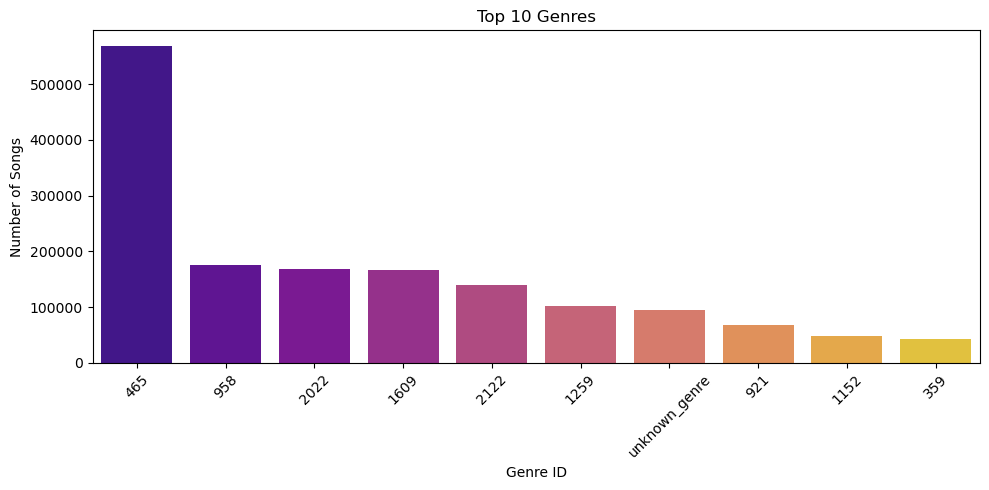

In [12]:
top_genres = df2['genre_ids'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='plasma')
plt.title('Top 10 Genres')
plt.xlabel('Genre ID')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

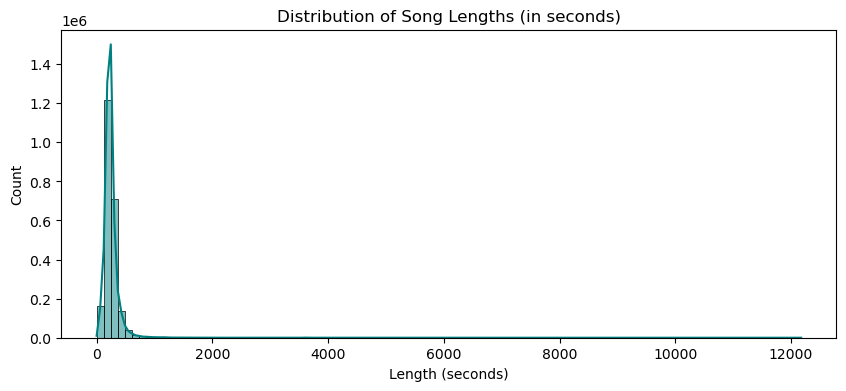

In [13]:
plt.figure(figsize=(10, 4))
sns.histplot(df2['song_length'] / 1000, bins=100, kde=True, color='teal')
plt.title('Distribution of Song Lengths (in seconds)')
plt.xlabel('Length (seconds)')
plt.ylabel('Count')
plt.show()

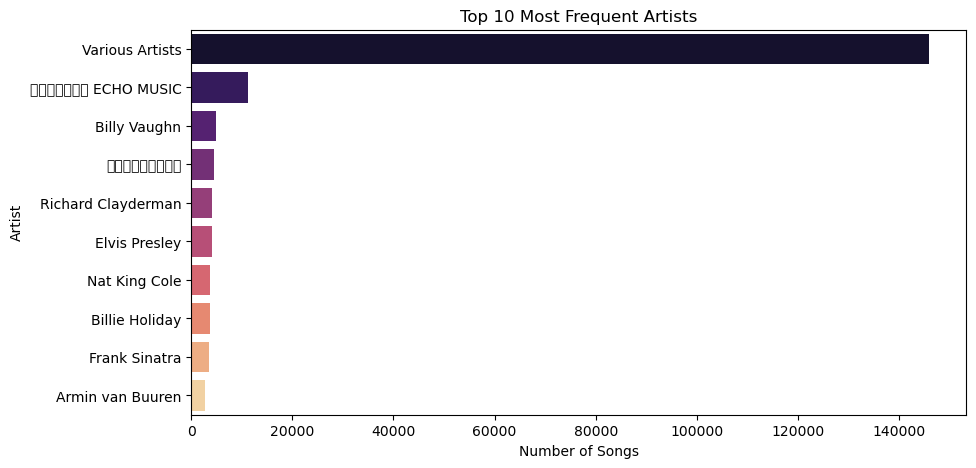

In [14]:
top_artists = df2['artist_name'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(y=top_artists.index, x=top_artists.values, palette='magma')
plt.title('Top 10 Most Frequent Artists')
plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.show()

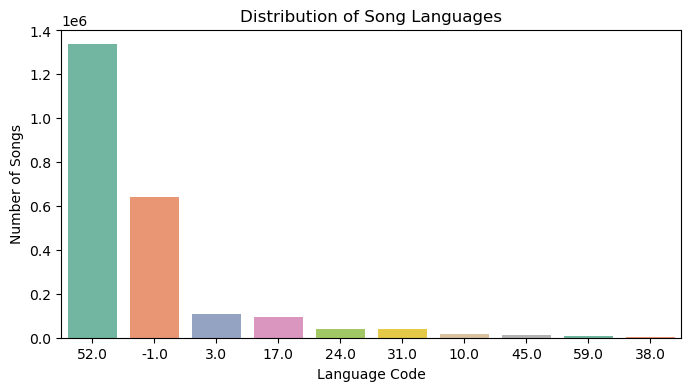

In [15]:
plt.figure(figsize=(8, 4))
sns.countplot(x='language', data=df2, palette='Set2', order=df2['language'].value_counts().index)
plt.title('Distribution of Song Languages')
plt.xlabel('Language Code')
plt.ylabel('Number of Songs')
plt.show()

In [16]:
# Share of songs where composer and lyricist are same
same_credit = (df2['composer'] == df2['lyricist'])
same_credit_ratio = same_credit.mean()

print(f"Percentage of songs where composer and lyricist are same: {same_credit_ratio:.2%}")

Percentage of songs where composer and lyricist are same: 9.48%


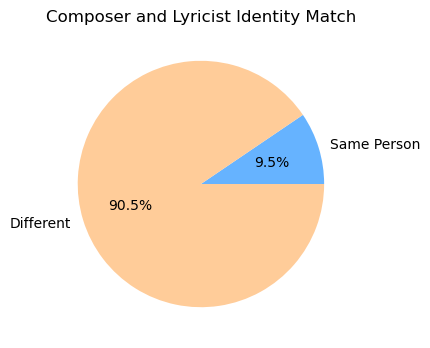

In [39]:
labels = ['Same Person', 'Different']
sizes = [same_credit_ratio, 1 - same_credit_ratio]

plt.figure(figsize=(4,4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ffcc99'])
plt.title("Composer and Lyricist Identity Match")
plt.show()

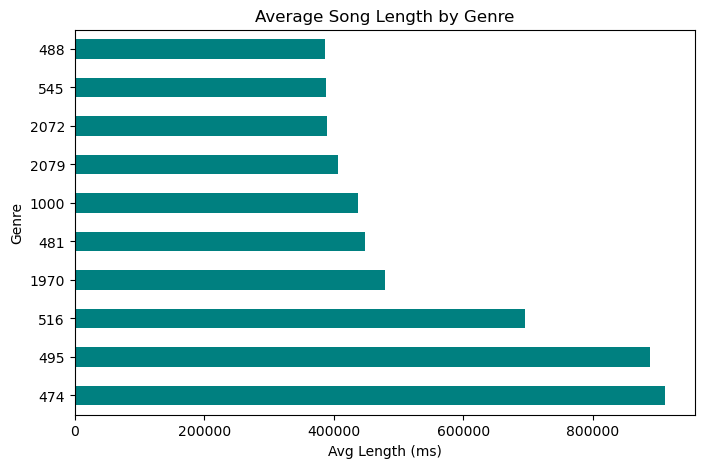

In [41]:
## Avg song length by genre
# Handle multi-genre: take first genre only
df2['primary_genre'] = df2['genre_ids'].str.split('|').str[0]
genre_length = df2.groupby('primary_genre')['song_length'].mean().sort_values(ascending=False).head(10)

genre_length.plot(kind='barh', figsize=(8,5), color='teal')
plt.title("Average Song Length by Genre")
plt.xlabel("Avg Length (ms)")
plt.ylabel("Genre")
plt.show()

C:\Users\honey\anaconda_new\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 35388 (\N{CJK UNIFIED IDEOGRAPH-8A3C}) missing from current font.
  fig.canvas.draw()
C:\Users\honey\anaconda_new\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 32882 (\N{CJK UNIFIED IDEOGRAPH-8072}) missing from current font.
  fig.canvas.draw()
C:\Users\honey\anaconda_new\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from current font.
  fig.canvas.draw()
C:\Users\honey\anaconda_new\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 27138 (\N{CJK UNIFIED IDEOGRAPH-6A02}) missing from current font.
  fig.canvas.draw()
C:\Users\honey\anaconda_new\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from current font.
  fig.canvas.draw()
C:\Users\honey\anaconda_new\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 26360 (\N{CJK UNIFIED IDEOGRAPH-66F8}) missing from cu

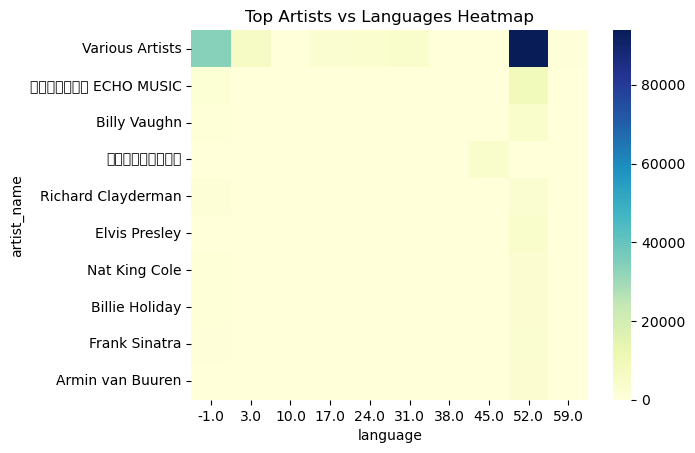

In [47]:
pivot_artist_lang = df2.pivot_table(index='artist_name', columns='language', aggfunc='size', fill_value=0)
top_artists = df2['artist_name'].value_counts().head(10).index
sns.heatmap(pivot_artist_lang.loc[top_artists], cmap='YlGnBu')
plt.title("Top Artists vs Languages Heatmap")
plt.show()

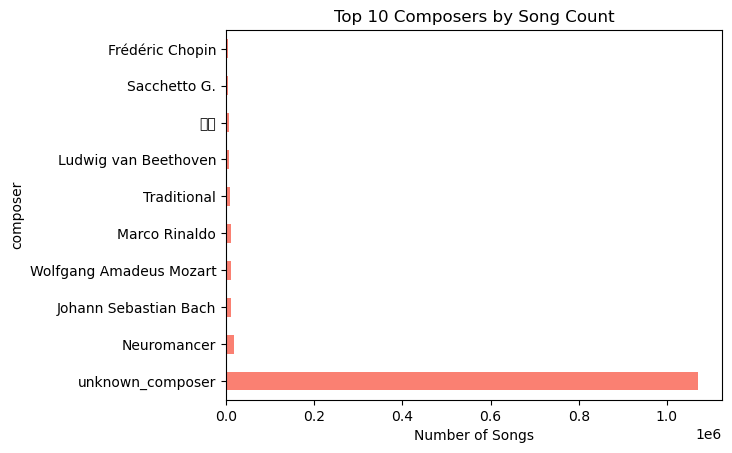

In [49]:
df2['composer'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title("Top 10 Composers by Song Count")
plt.xlabel("Number of Songs")
plt.show()

In [53]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/00/09/abb305dce85911b8fba382926cfc57f2f257729e25937fdcc63f3a1a67f9/wordcloud-1.9.4-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/299.9 kB ? eta -:--:--
   --- ----------------------------------- 30.7/299.9 kB 330.3 kB/s eta 0:00:01
   ----------- --------------------------- 92.2/299.9 kB 585.1 kB/s eta 0:00:01
   ---------------------------------------- 299.9/299.9 kB 1.5 MB/s eta 0:00:00


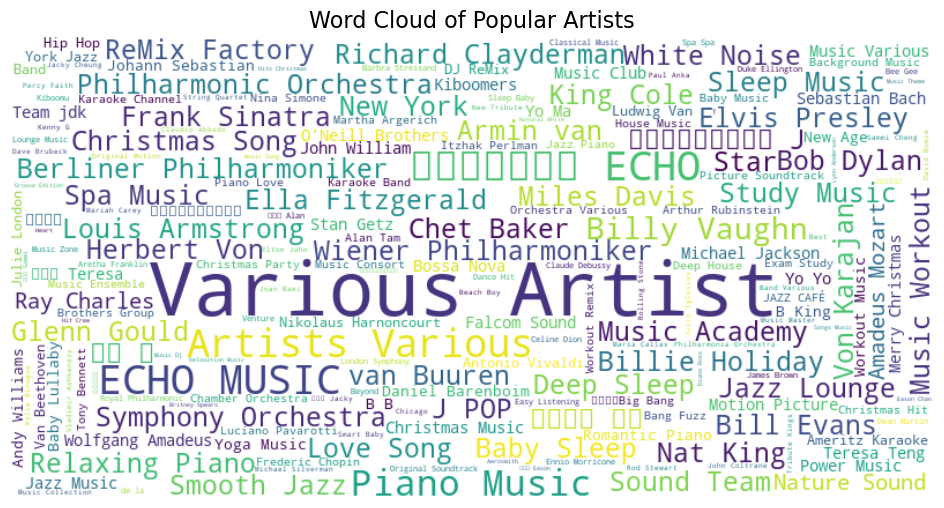

In [55]:
from wordcloud import WordCloud
# Join all artist names into one string
artist_text = ' '.join(df2['artist_name'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(artist_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Popular Artists', fontsize=16)
plt.show()

In [57]:
print("Unique artists:", df2['artist_name'].nunique())
print("Unique composers:", df2['composer'].nunique())
print("Unique lyricists:", df2['lyricist'].nunique())

Unique artists: 222363
Unique composers: 329823
Unique lyricists: 110925


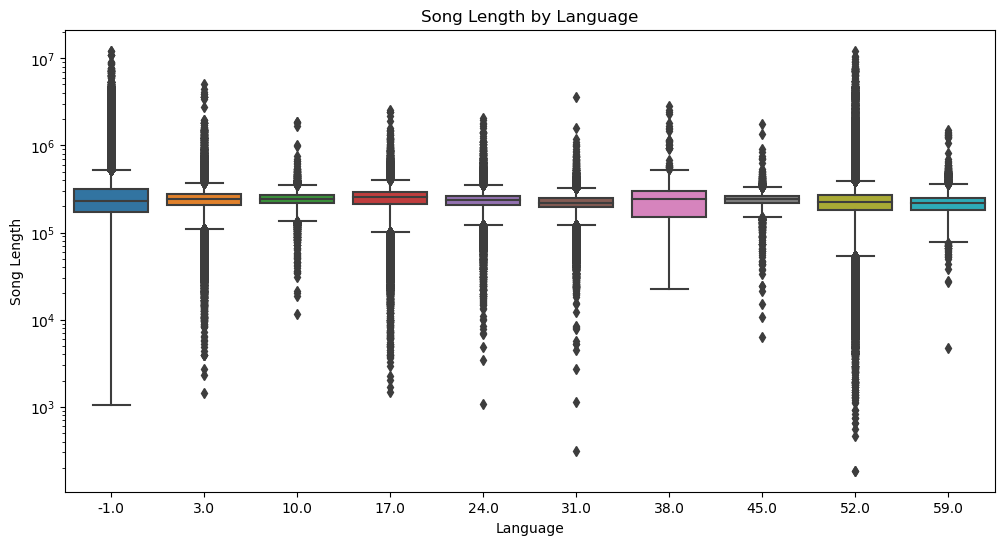

In [59]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='language', y='song_length', data=df2)
plt.title('Song Length by Language')
plt.xlabel('Language')
plt.ylabel('Song Length')
plt.yscale('log')  # Use log if outliers stretch the scale
plt.show()


In [61]:
# Convert genre_ids to lists
df2['genre_ids'] = df2['genre_ids'].fillna('').apply(lambda x: x.split('|') if x else [])

# Convert language to categorical
df2['language'] = df2['language'].astype('category')

# Convert song length to seconds
df2['song_length_sec'] = df2['song_length'] / 1000

# Optional: lowercase all artist names
df2['artist_name'] = df2['artist_name'].str.lower().str.strip()


In [69]:
df3 = pd.read_csv("song_extra_info.csv")

In [71]:
df3.head(2)

,song_id,name,isrc
0,LP7pLJoJFBvyuUwvu+oLzjT+bI+UeBPURCecJsX1jjs=,我們,TWUM71200043
1,ClazTFnk6r0Bnuie44bocdNMM3rdlrq0bCGAsGUWcHE=,Let Me Love You,QMZSY1600015


In [73]:
df3.shape

(1048575, 3)

In [75]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   song_id  1048575 non-null  object
 1   name     1048573 non-null  object
 2   isrc     967252 non-null   object
dtypes: object(3)
memory usage: 24.0+ MB


In [77]:
df3.isnull().sum()

song_id        0
name           2
isrc       81323
dtype: int64

In [81]:
# Fill missing values
df3['name'].fillna('Unknown', inplace=True)
df3['isrc'].fillna('Unavailable', inplace=True)

In [83]:
# Step 2: Merge on 'song_id' with a left join
songs_merge = df2.merge(df3, on='song_id', how='left')

Merged DataFrame shape: (2296320, 11)
                                        song_id  song_length genre_ids  \
0  CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=       247640     [465]   
1  o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=       197328     [444]   
2  DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=       231781     [465]   
3  dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=       273554     [465]   
4  W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=       140329     [726]   

        artist_name                            composer          lyricist  \
0  張信哲 (jeff chang)                                  董貞               何啟弘   
1         blackpink  TEDDY|  FUTURE BOUNCE|  Bekuh BOOM             TEDDY   
2      super junior                    unknown_composer  unknown_lyricist   
3             s.h.e                                 湯小康               徐世珍   
4              貴族精選                         Traditional       Traditional   

  language primary_genre  song_length_sec             

In [87]:
# Step 3: Display shape and preview
print("Merged DataFrame shape:", songs_merge.shape)
songs_merge.head(2)

Merged DataFrame shape: (2296320, 11)


,song_id,song_length,genre_ids,artist_name,composer,lyricist,language,primary_genre,song_length_sec,name,isrc
0,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,247640,[465],張信哲 (jeff chang),董貞,何啟弘,3.0,465,247.640,焚情,TWB531410010
1,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=,197328,[444],blackpink,TEDDY| FUTURE BOUNCE| Bekuh BOOM,TEDDY,31.0,444,197.328,PLAYING WITH FIRE,Unavailable


In [89]:
# Count how many rows have 'unknown' in the merged columns
unavailable_summary = songs_merge[['name', 'isrc']].apply(lambda col: (col == 'unknown').sum())

print("Number of 'unknown' values in each column:")
print(unavailable_summary)

# Optionally, also get percentage
print("\nPercentage of unavailable data:")
print((unavailable_summary / songs_merge.shape[0] * 100).round(2))


Number of 'unknown' values in each column:
name    1
isrc    0
dtype: int64

Percentage of unavailable data:
name    0.0
isrc    0.0
dtype: float64


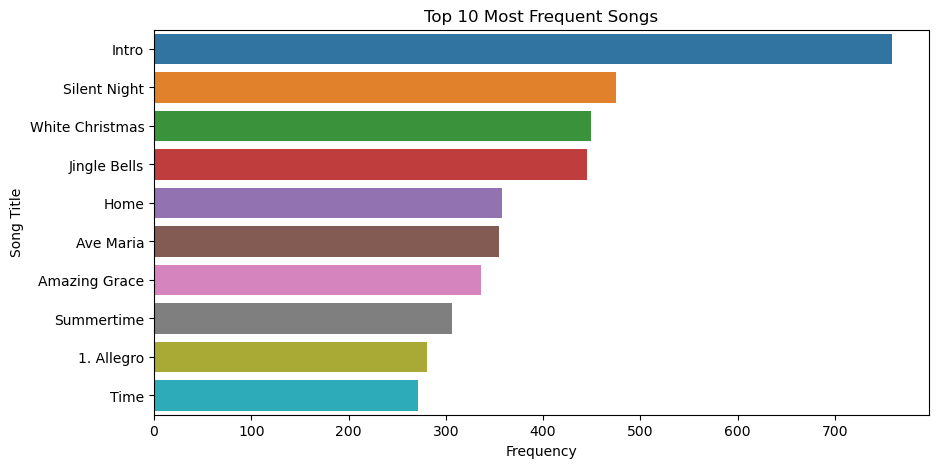

In [91]:
top_songs = songs_merge['name'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_songs.values, y=top_songs.index)
plt.title('Top 10 Most Frequent Songs')
plt.xlabel('Frequency')
plt.ylabel('Song Title')
plt.show()

In [95]:
# Ensure genre_ids is treated as a string
songs_merge['genre_ids'] = songs_merge['genre_ids'].astype(str)

# Split genre_ids by '|' and explode into separate rows
songs_exploded = songs_merge.assign(genre_id=songs_merge['genre_ids'].str.split('|')).explode('genre_id')

# Now group by genre_id and get average song length
avg_length_per_genre = songs_exploded.groupby('genre_id')['song_length'].mean().sort_values(ascending=False)

# Show top 10
print(avg_length_per_genre.head(10))


genre_id
['1969', '786', '2100']     2.832230e+06
['1969', '465', '2100']     1.347814e+06
['1096', '958']             1.284257e+06
['873', '545']              1.168195e+06
['1152', '873', '947']      9.434058e+05
['474']                     9.120666e+05
['495']                     8.878777e+05
['1152', '873']             8.150285e+05
['516', '829']              7.240090e+05
['1609', '1969', '2100']    7.186514e+05
Name: song_length, dtype: float64


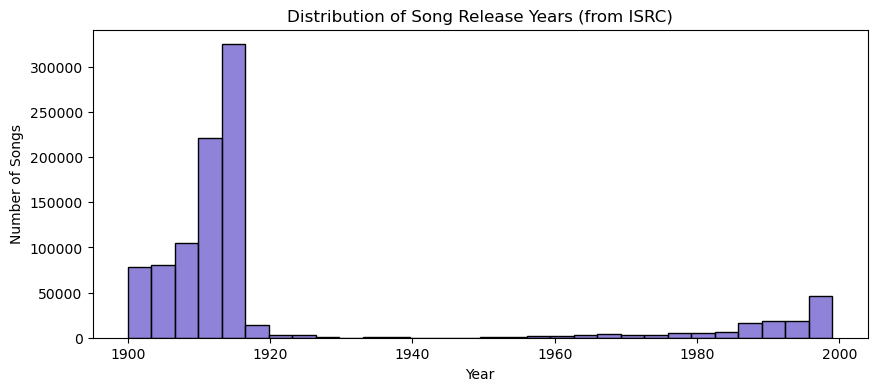

In [97]:
# Extract year from ISRC (positions 5–6 give year in many ISRC codes)
songs_merge['isrc_year'] = songs_merge['isrc'].str[5:7]
songs_merge['isrc_year'] = pd.to_numeric(songs_merge['isrc_year'], errors='coerce')
songs_merge['isrc_year'] = songs_merge['isrc_year'].apply(lambda x: 1900 + x if x < 25 else 1900 + x if x < 100 else x)

# Plot year distribution
plt.figure(figsize=(10,4))
sns.histplot(songs_merge['isrc_year'].dropna(), bins=30, color='slateblue')
plt.title('Distribution of Song Release Years (from ISRC)')
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.show()


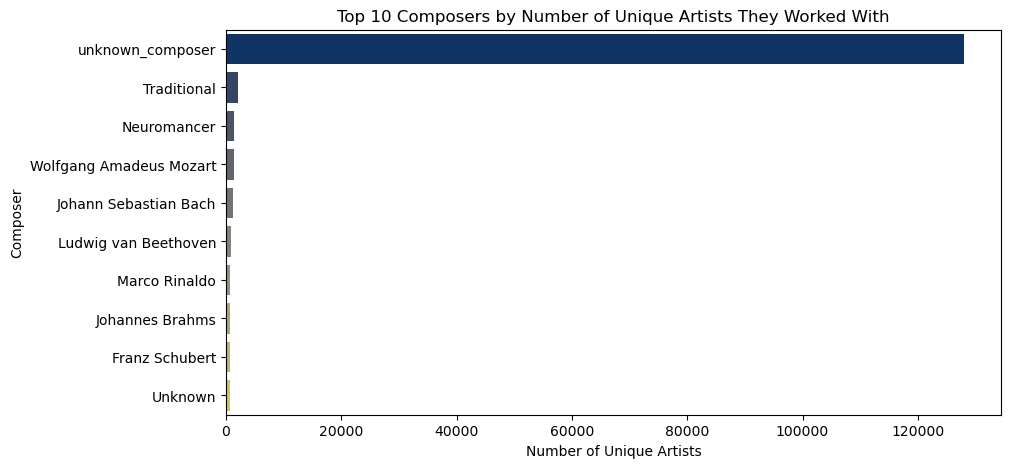

In [99]:
composer_counts = songs_merge.groupby('composer')['artist_name'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=composer_counts.values, y=composer_counts.index, palette='cividis')
plt.title('Top 10 Composers by Number of Unique Artists They Worked With')
plt.xlabel('Number of Unique Artists')
plt.ylabel('Composer')
plt.show()


In [103]:
collab = songs_merge.groupby(['composer', 'lyricist', 'artist_name']).size().reset_index(name='count')
top_collab = collab.sort_values('count', ascending=False).head(10)

print(top_collab)

                     composer          lyricist                 artist_name  \
581400       unknown_composer  unknown_lyricist             various artists   
554842       unknown_composer  unknown_lyricist          richard clayderman   
572885       unknown_composer  unknown_lyricist               the kiboomers   
141178  Falcom Sound Team jdk  unknown_lyricist       falcom sound team jdk   
550890       unknown_composer  unknown_lyricist         power music workout   
584610       unknown_composer  unknown_lyricist     wolfgang amadeus mozart   
573968       unknown_composer  unknown_lyricist  the o'neill brothers group   
572851       unknown_composer  unknown_lyricist         the karaoke channel   
478613       unknown_composer  unknown_lyricist                billy vaughn   
495967       unknown_composer  unknown_lyricist            dj remix factory   

        count  
581400  54761  
554842   3911  
572885   2230  
141178   1996  
550890   1970  
584610   1747  
573968   1596  
57

In [107]:
songs_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296320 entries, 0 to 2296319
Data columns (total 12 columns):
 #   Column           Dtype   
---  ------           -----   
 0   song_id          object  
 1   song_length      int64   
 2   genre_ids        object  
 3   artist_name      object  
 4   composer         object  
 5   lyricist         object  
 6   language         category
 7   primary_genre    object  
 8   song_length_sec  float64 
 9   name             object  
 10  isrc             object  
 11  isrc_year        float64 
dtypes: category(1), float64(2), int64(1), object(8)
memory usage: 194.9+ MB


In [111]:
songs_merge.describe(include ='all')

,song_id,song_length,genre_ids,artist_name,composer,lyricist,language,primary_genre,song_length_sec,name,isrc,isrc_year
count,2296320,2.296320e+06,2296320,2296320,2296320,2296320,2296320.0,2296320,2.296320e+06,1048307,1048307,966995.000000
unique,2296320,NaN,1046,221789,329823,110925,10.0,183,NaN,614807,845619,NaN
top,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,NaN,['465'],various artists,unknown_composer,unknown_lyricist,52.0,465,NaN,Intro,Unavailable,NaN
freq,1,NaN,567911,145916,1071358,1945306,1336695.0,584983,NaN,759,81312,NaN
mean,NaN,2.469935e+05,NaN,NaN,NaN,NaN,NaN,NaN,2.469935e+02,NaN,NaN,1922.073283
std,NaN,1.609200e+05,NaN,NaN,NaN,NaN,NaN,NaN,1.609200e+02,NaN,NaN,27.630581
min,NaN,1.850000e+02,NaN,NaN,NaN,NaN,NaN,NaN,1.850000e-01,NaN,NaN,1900.000000
25%,NaN,1.836000e+05,NaN,NaN,NaN,NaN,NaN,NaN,1.836000e+02,NaN,NaN,1909.000000
50%,NaN,2.266270e+05,NaN,NaN,NaN,NaN,NaN,NaN,2.266270e+02,NaN,NaN,1913.000000
75%,NaN,2.772690e+05,NaN,NaN,NaN,NaN,NaN,NaN,2.772690e+02,NaN,NaN,1916.000000


In [115]:
# Fill missing ISRC info
songs_merge['isrc'] = songs_merge['isrc'].fillna('Unavailable')
songs_merge['isrc_year'] = songs_merge['isrc_year'].fillna(-1).astype(int)

# Fill missing name
songs_merge['name'] = songs_merge['name'].fillna('unknown')

# Cap outlier song lengths
songs_merge['song_length_sec'] = songs_merge['song_length_sec'].clip(upper=songs_merge['song_length_sec'].quantile(0.99))

In [117]:
songs_merge.describe(include ='all')

,song_id,song_length,genre_ids,artist_name,composer,lyricist,language,primary_genre,song_length_sec,name,isrc,isrc_year
count,2296320,2.296320e+06,2296320,2296320,2296320,2296320,2296320.0,2296320,2.296320e+06,2296320,2296320,2.296320e+06
unique,2296320,NaN,1046,221789,329823,110925,10.0,183,NaN,614807,845619,NaN
top,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,NaN,['465'],various artists,unknown_composer,unknown_lyricist,52.0,465,NaN,unknown,Unavailable,NaN
freq,1,NaN,567911,145916,1071358,1945306,1336695.0,584983,NaN,1248014,1329325,NaN
mean,NaN,2.469935e+05,NaN,NaN,NaN,NaN,NaN,NaN,2.417432e+02,NaN,NaN,8.088184e+02
std,NaN,1.609200e+05,NaN,NaN,NaN,NaN,NaN,NaN,1.045392e+02,NaN,NaN,9.496611e+02
min,NaN,1.850000e+02,NaN,NaN,NaN,NaN,NaN,NaN,1.850000e-01,NaN,NaN,-1.000000e+00
25%,NaN,1.836000e+05,NaN,NaN,NaN,NaN,NaN,NaN,1.836000e+02,NaN,NaN,-1.000000e+00
50%,NaN,2.266270e+05,NaN,NaN,NaN,NaN,NaN,NaN,2.266270e+02,NaN,NaN,-1.000000e+00
75%,NaN,2.772690e+05,NaN,NaN,NaN,NaN,NaN,NaN,2.772690e+02,NaN,NaN,1.912000e+03


In [119]:
songs_merge.to_csv("songs_eda.csv", index=False)